# Full re-fabrication baseline, tuned drive and mapped effective device (referee concern 1)

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg')
from IPython.display import Image, display
RUN = False   # set True to recompute the data of this notebook (cost given in the Compute section)
def show(pdf, dpi=110):
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
ld = lambda n: np.load(os.path.join('data', n), allow_pickle=True)


## Problem
The referee noted that the original re-fabrication grid, $(g,\kappa,\epsilon)$ at fixed detuning and emitter decay, does not optimize all parameters that the squeezing controls mimic. The controls move the effective cavity frequency $\Omega_a=\omega_a/\cosh 2r$, the couplings $g\cosh r$ and $g\sinh r$, the input strength $\epsilon_{\rm eff}$ and the emitter relaxation. Three questions:
1. What does a device re-fabricated in **all six** parameters $(g,\kappa,\gamma,\omega_a,\omega_q,\epsilon)$ achieve?
2. The detunings are measured from the drive carrier, so the **drive frequency** is a post-fabrication knob. What does squeezing add to a base whose drive amplitude *and* frequency are optimized?
3. How much of that squeezing gain would an **ordinary device with the same effective parameters** reproduce (mapped effective device)?

## Method
* `rev_refab.py`: Latin hypercube (119 points + the amplitude-optimized base) and three bounded Nelder–Mead refinements in normalized (log for rates) coordinates, 300 evaluations (460 for Mackey–Glass), photon budget $\max_t\langle a^\dagger a\rangle\le 2.5$ by penalty, $N_c=10$, optimum checked at $N_c=14$.
* `rev_base2.py`: $(\epsilon,\delta)$ grid + Nelder–Mead at zero squeezing, then $3\times3\times8$ scans of $(r,r_e,\Delta\theta)$ for $\phi_d\in\{0,\pi/2\}$ and 60 evaluations of convergent-gradient descent; cutoff check at $N_c+4$.
* `rev_post.py`: mapped effective device, bare $\gamma$ found by bisection so that the mean $\gamma^{\rm eff}_{x,y,z}$ matches the squeezed device.

## Compute (≈ 35 min for re-fabrication, ≈ 25 min for the tuned base, 1 core)

In [2]:
if RUN:
    for s in ('rev_refab.py', 'rev_base2.py', 'rev_post.py'): subprocess.run([sys.executable, s], check=True)

## Results

In [3]:
rf, b2, po, bs = ld('rev_refab.npz'), ld('rev_base2.npz'), ld('rev_post.npz'), ld('base.npz')
pc = lambda a, b: 100 * (1 - a / b)
print('%-8s %10s %10s %10s %10s %10s %10s' % ('task', 'amp base', 'tuned', 'squeezed', 'mapped', 'refab', 'sq/refab'))
for n in ['mg', 'narma', 'lorenz', 'nce', 'laser']:
    Lb = bs[f'{n}_eps'][:, 1].min(); Lt = b2[f'{n}_base2'][2]; Ls = b2[f'{n}_Lsq2'][0][0]; Lm = po[f'{n}_map2_Lfull'][0]; Lr = rf[f'{n}_best'][6]
    print('%-8s %10.3e %10.3e %10.3e %10.3e %10.3e %10.2f' % (n, Lb, Lt, Ls, Lm, Lr, Ls / Lr))
    print('         tuned vs amp %+.0f%%  squeezing vs tuned %+.0f%%  mapped vs tuned %+.0f%%  refab vs tuned %+.0f%%' % (-pc(Lt, Lb), -pc(Ls, Lt), -pc(Lm, Lt), -pc(Lr, Lt)))

task       amp base      tuned   squeezed     mapped      refab   sq/refab
mg        6.524e-03  3.896e-03  3.863e-03  3.902e-03  1.344e-03       2.87
         tuned vs amp -40%  squeezing vs tuned -1%  mapped vs tuned +0%  refab vs tuned -66%
narma     5.021e-03  2.710e-03  1.943e-03  2.925e-03  2.208e-03       0.88
         tuned vs amp -46%  squeezing vs tuned -28%  mapped vs tuned +8%  refab vs tuned -19%
lorenz    9.544e-02  8.531e-03  6.510e-03  8.492e-03  4.834e-03       1.35
         tuned vs amp -91%  squeezing vs tuned -24%  mapped vs tuned -0%  refab vs tuned -43%
nce       2.470e-01  2.028e-01  6.889e-02  1.483e-01  3.045e-02       2.26
         tuned vs amp -18%  squeezing vs tuned -66%  mapped vs tuned -27%  refab vs tuned -85%
laser     2.126e+02  7.169e+01  6.379e+01  6.826e+01  2.875e+01       2.22
         tuned vs amp -66%  squeezing vs tuned -11%  mapped vs tuned -5%  refab vs tuned -60%


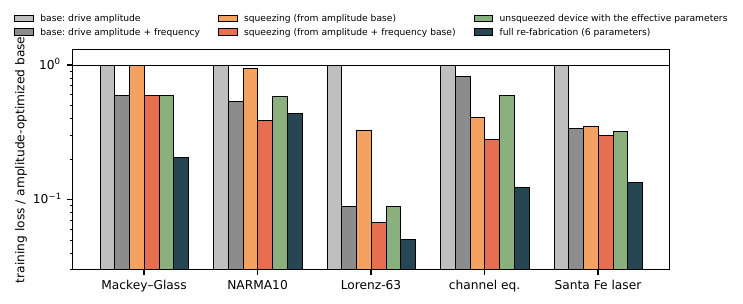

In [4]:
subprocess.run([sys.executable, 'make_rev.py'], check=True, capture_output=True); show('../paper/figs/fig_refab.pdf')

In [5]:
print(open('../paper/refabtable.tex').read())

\begin{tabular}{lcccccccc}
\toprule
task & $g$ & $\kappa$ & $\gamma$ & $\omega_a$ & $\omega_q$ & $\epsilon$ & $\max\langle a^\dagger a\rangle$ & evaluations\\
\midrule
Mackey–Glass & 1.16 & 0.06 & 0.10 & 2.00 & 2.00 & 0.75 & 0.34 & 460\\
NARMA10 & 1.20 & 0.16 & 0.06 & 0.94 & 1.54 & 0.06 & 0.08 & 300\\
Lorenz-63 & 0.69 & 0.16 & 0.54 & 1.28 & 1.90 & 1.60 & 2.33 & 300\\
channel eq. & 0.12 & 0.99 & 0.48 & 0.64 & 1.64 & 0.06 & 0.01 & 300\\
Santa Fe laser & 1.01 & 0.65 & 0.05 & 1.63 & 0.32 & 0.35 & 0.16 & 300\\
\bottomrule
\end{tabular}


## Interpretation
* The drive frequency alone captures most of what squeezing appeared to give against a fixed drive on Lorenz and the laser; those were detuning gains.
* Over the fully tuned drive, squeezing adds a gain on NARMA10, Lorenz and channel equalization that the mapped ordinary device does **not** reproduce: it comes from the counter-rotating coupling $g\sinh r$ and the anisotropic, phase-sensitive noise of the squeezed bath.
* Full re-fabrication beats the squeezed device on four of five tasks (NARMA10 is the exception), with several optima at the search bounds. The claim that squeezing recovers or exceeds the re-fabrication gain is withdrawn.